# C05 — recurrent networks and LSTMs on Irish weather data

STAT41140: AI for weather and climate. Companion notebook for the RNN and LSTM lecture.

We forecast **Dublin's 2 m temperature one hour ahead** from the previous **24 hours** of Dublin
temperature, first with a vanilla RNN and then with an LSTM.

Three things this notebook insists on, all of which are easy to get wrong:

1. **A baseline first.** Persistence — "the temperature in an hour will be what it is now" — is
   computed before any model, in degrees Celsius. A model that cannot beat it has taught us
   nothing.
2. **A controlled comparison.** If the LSTM has a better architecture *and* fourteen times as many
   parameters, a win tells you nothing about which one was responsible. We match the hidden size,
   then vary capacity separately.
3. **No leakage.** Windows are cut *inside* each split, never across the whole series, and the
   scaler is fitted on the training period alone.

We also do two things by hand: the five-step board example from the slides, and a direct
measurement of how fast gradients vanish in an RNN and how much the LSTM's cell state helps.

**Data.** Put `era5_ireland3_t2m_wind_2024.csv` next to this notebook, or edit `CSV_PATH` below.
If the file is missing, the notebook generates a clearly-labelled synthetic stand-in so everything
still runs — but the numbers are then simulated, and the notebook says so loudly.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn

plt.rcParams.update({"figure.figsize": (10, 3.4), "figure.dpi": 110, "savefig.dpi": 200,
                     "savefig.bbox": "tight", "font.size": 11,
                     "axes.grid": True, "grid.alpha": 0.3})
FIGS = Path("figs_c05"); FIGS.mkdir(exist_ok=True)
np.set_printoptions(precision=4, suppress=True)
torch.set_printoptions(precision=4)

CSV_PATH = Path("era5_ireland3_t2m_wind_2024.csv")
TARGET = "Dublin_t2m_degC"


def make_surrogate(n=8784, seed=11):
    '''A stand-in with the right shape and roughly the right statistics. NOT real data.'''
    rng = np.random.default_rng(seed)
    t = np.arange(n); doy = t / 24.0

    def ar1(rho, sd):
        e = np.zeros(n); z = rng.normal(0, sd, n)
        for i in range(1, n):
            e[i] = rho * e[i - 1] + z[i]
        return e

    common = ar1(0.98, 0.55)                      # shared synoptic variability
    out = {"time": pd.date_range("2024-01-01", periods=n, freq="h")}
    for city, base, samp, damp in [("Dublin", 10.2, 5.0, 2.4),
                                   ("Galway", 10.6, 4.4, 2.0),
                                   ("Cork",   10.8, 4.6, 2.2)]:
        out[f"{city}_t2m_degC"] = (base
                                   + samp * np.sin(2 * np.pi * (doy - 80) / 366)   # seasonal
                                   + damp * np.sin(2 * np.pi * (t / 24.0 - 9))     # diurnal
                                   + common + ar1(0.95, 0.25) + rng.normal(0, 0.12, n))
    for city, base in [("Dublin", 6.4), ("Galway", 7.2), ("Cork", 5.9)]:
        out[f"{city}_wind_speed10m_ms"] = np.abs(base + ar1(0.97, 1.1) + rng.normal(0, 0.4, n))
    return pd.DataFrame(out)


if CSV_PATH.exists():
    df = pd.read_csv(CSV_PATH, parse_dates=["time"])
    USING_REAL_DATA = True
else:
    df = make_surrogate()
    USING_REAL_DATA = False
    print("!" * 78)
    print("!!  era5_ireland3_t2m_wind_2024.csv NOT FOUND - using a SYNTHETIC stand-in.")
    print("!!  The code is identical, but every number below is from simulated data.")
    print("!!  Put the real CSV next to this notebook and re-run to get the real answers.")
    print("!" * 78)

df = df.sort_values("time").reset_index(drop=True)
TAG = "" if USING_REAL_DATA else "  [SYNTHETIC DATA]"
print(f"\n{len(df)} rows, {df['time'].min()} to {df['time'].max()}")
df.head()


8784 rows, 2024-01-01 00:00:00 to 2024-12-31 23:00:00


,time,Dublin_t2m_degC,Galway_t2m_degC,Cork_t2m_degC,Dublin_wind_speed10m_ms,Galway_wind_speed10m_ms,Cork_wind_speed10m_ms
0,2024-01-01 00:00:00,5.763580,6.396393,5.617096,8.426119,6.120335,4.927529
1,2024-01-01 01:00:00,5.445953,5.922516,5.094391,8.082199,5.639297,4.454760
2,2024-01-01 02:00:00,5.434723,5.518707,4.604645,7.943061,4.928046,3.922362
3,2024-01-01 03:00:00,5.265533,5.257721,4.111237,7.585234,4.344268,3.177118
4,2024-01-01 04:00:00,5.138092,5.163483,3.917389,7.084112,3.941263,2.874048


## 1. The board example, in five lines of numpy

This is the calculation from the slides. One input variable (temperature), one hidden unit, a
five-hour window. Everything is chosen so it can be done with a calculator.

The input is the temperature **anomaly**, $x_t = T_t - 21$, for the same reason as in C01: feeding
raw temperatures of about 21 into a $\tanh$ saturates it immediately and the network learns
nothing.

$$h_t = \tanh\!\left(w_{xh}\,x_t + w_{hh}\,h_{t-1} + b_h\right), \qquad
  \hat{y} = w_{hy}\,h_5 + b_y$$

with $w_{xh} = 1$, $w_{hh} = 0.5$, $b_h = 0$, $w_{hy} = 2$, $b_y = 21$, and $h_0 = 0$.

In [2]:
T_obs = np.array([20.9, 20.5, 21.0, 21.9, 22.0])       # five days of temperature, degC
x = T_obs - 21.0                                        # anomalies
w_xh, w_hh, b_h, w_hy, b_y = 1.0, 0.5, 0.0, 2.0, 21.0

h = 0.0
print(f"{'t':>2} {'x_t':>6} {'z_t':>9} {'h_t':>9}")
for t, x_t in enumerate(x, start=1):
    z = w_xh * x_t + w_hh * h + b_h
    h = np.tanh(z)
    print(f"{t:>2} {x_t:>6.1f} {z:>9.4f} {h:>9.4f}")

y_hat = w_hy * h + b_y
print(f"\nforecast for day 6: {y_hat:.4f} degC")
print(f"persistence would say: {T_obs[-1]:.1f} degC")

 t    x_t       z_t       h_t
 1   -0.1   -0.1000   -0.0997
 2   -0.5   -0.5498   -0.5004
 3    0.0   -0.2502   -0.2451
 4    0.9    0.7774    0.6512
 5    1.0    1.3256    0.8682

forecast for day 6: 22.7363 degC
persistence would say: 22.0 degC


Two things to notice, both of which will come back later:

- $h_t$ is a **running summary**, not a memory of individual days. By $t = 5$ the contribution of
  day 1 has been through $\tanh$ four times and is almost gone. That is the vanishing-gradient
  problem in its forward-pass form, and we measure it in section 7.
- The RNN forecasts 22.74 °C against persistence's 22.0 °C. It has noticed the temperature is
  rising. Whether that is *useful* is the question the rest of the notebook is about.

### The same thing in PyTorch

Worth doing once: it confirms that `nn.RNN` is exactly the recurrence above, and it forces us to
meet PyTorch's most notorious default.

In [3]:
rnn = nn.RNN(input_size=1, hidden_size=1, nonlinearity="tanh", batch_first=True)
with torch.no_grad():                       # plant our own weights
    rnn.weight_ih_l0.fill_(w_xh); rnn.weight_hh_l0.fill_(w_hh)
    rnn.bias_ih_l0.fill_(b_h);    rnn.bias_hh_l0.zero_()

seq = torch.tensor(x, dtype=torch.float32).reshape(1, 5, 1)     # (batch, seq, feature)
with torch.no_grad():
    out, h_n = rnn(seq)
print("hidden states:", out.squeeze().numpy())
print("forecast     :", (w_hy * out[0, -1, 0] + b_y).item())

hidden states: [-0.0997 -0.5004 -0.2451  0.6512  0.8682]
forecast     : 22.73634910583496


### The `batch_first` trap

`nn.RNN` and `nn.LSTM` default to `batch_first=False`, meaning they expect
`(seq, batch, feature)`. Hand them a `(batch, seq, feature)` tensor and **nothing errors** — the
batch dimension is silently treated as time, so the model runs "through time" across unrelated
sequences. The numbers are simply wrong.

In [4]:
rnn_bf   = nn.RNN(1, 4, batch_first=True)
rnn_nobf = nn.RNN(1, 4, batch_first=False)
rnn_nobf.load_state_dict(rnn_bf.state_dict())          # identical weights

batch = torch.randn(6, 12, 1)                          # (batch=6, seq=12, feature=1)
with torch.no_grad():
    a, _ = rnn_bf(batch)
    b, _ = rnn_nobf(batch)

print("batch_first=True  final hidden state:", a[:, -1, :][0].numpy())
print("batch_first=False final hidden state:", b[:, -1, :][0].numpy())
print("\nsame weights, same input, different answers:", not torch.allclose(a[:, -1, :], b[:, -1, :]))
print("Always pass batch_first=True, or transpose deliberately.")

batch_first=True  final hidden state: [ 0.1959 -0.2078  0.4883 -0.4826]
batch_first=False final hidden state: [ 0.3217  0.1418  0.4623 -0.2231]

same weights, same input, different answers: True
Always pass batch_first=True, or transpose deliberately.


## 2. Splitting and windowing without leaking

Two rules, both broken often enough to be worth stating:

1. **Split chronologically.** A random split lets the model see 3 p.m. when predicting 2 p.m.
   Neighbouring hours of temperature are almost the same number, so a random split gives a
   spectacularly good — and completely fake — test score.
2. **Cut the windows inside each split, not across the whole series.** If you window first and
   split second, the last few training windows reach forward into the validation period. It is a
   small effect here (seven windows) but it is the same mistake as (1) in miniature, and it costs
   nothing to avoid.

The scaler is fitted on the **training period only**, for the same reason: the validation and test
means are not things we are allowed to know.

In [5]:
WINDOW = 24                                   # hours of history
series = df[TARGET].to_numpy(dtype=np.float64)
n = len(series)
i_tr, i_va = int(0.70 * n), int(0.85 * n)

raw = {"train": series[:i_tr], "val": series[i_tr:i_va], "test": series[i_va:]}
print({k: len(v) for k, v in raw.items()})

mu, sd = raw["train"].mean(), raw["train"].std()
print(f"training mean {mu:.3f} degC, training sd {sd:.3f} degC")


def make_windows(x_raw, T=WINDOW):
    '''Windows built WITHIN one split, so no window crosses a split boundary.'''
    z = (x_raw - mu) / sd
    X = np.stack([z[t:t + T] for t in range(len(z) - T)])[..., None]   # (N, T, 1)
    y = z[T:][:, None]                                                 # (N, 1)
    last_obs = x_raw[T - 1:-1][:, None]        # last observed value, in degC: persistence
    truth = x_raw[T:][:, None]                 # target, in degC
    return (torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32),
            last_obs, truth)


data = {k: make_windows(v) for k, v in raw.items()}
for k, (X, y, _, _) in data.items():
    print(f"{k:>5}: X {tuple(X.shape)}  y {tuple(y.shape)}")

{'train': 6148, 'val': 1318, 'test': 1318}
training mean 10.635 degC, training sd 4.474 degC
train: X (6124, 24, 1)  y (6124, 1)
  val: X (1294, 24, 1)  y (1294, 1)
 test: X (1294, 24, 1)  y (1294, 1)


## 3. The baseline, before any model

Persistence: $\hat{T}_{t+1} = T_t$. No parameters, no training, no data beyond the last
observation. If a neural network cannot beat this, the network is not forecasting — it is
laundering the last observation.

In [6]:
def rmse(pred, truth):
    return float(np.sqrt(np.mean((np.asarray(pred) - np.asarray(truth)) ** 2)))


_, _, last_obs_te, truth_te = data["test"]
RMSE_PERSIST = rmse(last_obs_te, truth_te)
print(f"persistence test RMSE: {RMSE_PERSIST:.3f} degC{TAG}")
print(f"(for scale: the standard deviation of the test temperatures is "
      f"{truth_te.std():.3f} degC)")

persistence test RMSE: 0.454 degC
(for scale: the standard deviation of the test temperatures is 3.346 degC)


## 4. Two models, matched

`TinyRNN` and `TinyLSTM` differ in **one** thing: the recurrent cell. Same hidden size, same
readout, same optimiser, same seed, same number of epochs.

Before training, count the parameters. For hidden size $h$ and one input feature, a vanilla RNN
cell holds $h^2 + h$ weights and $2h$ biases; an LSTM holds four copies of that, one per gate
(input, forget, output, candidate). The factor of four *is* the gates — it is not a mystery, and
it is what slide 24's "more parameters" means.

In [7]:
class Tiny(nn.Module):
    '''One recurrent layer, one linear readout of the final hidden state.'''
    def __init__(self, cell="rnn", hidden=16):
        super().__init__()
        if cell == "rnn":
            self.rec = nn.RNN(1, hidden, nonlinearity="tanh", batch_first=True)
        else:
            self.rec = nn.LSTM(1, hidden, batch_first=True)
        self.head = nn.Linear(hidden, 1)

    def forward(self, x):
        out, _ = self.rec(x)
        return self.head(out[:, -1, :])        # the LAST time step only


def n_params(m):
    return sum(p.numel() for p in m.parameters())


for h in (16, 32):
    r, l = Tiny("rnn", h), Tiny("lstm", h)
    print(f"hidden={h:>2}:  RNN {n_params(r):>5}   LSTM {n_params(l):>5}   "
          f"ratio {n_params(l) / n_params(r):.2f}x")

hidden=16:  RNN   321   LSTM  1233   ratio 3.84x
hidden=32:  RNN  1153   LSTM  4513   ratio 3.91x


The ratio is a little under 4 because the readout layer and its bias are the same in both.

Now train. Nothing exotic: Adam, mean squared error on the standardised series, gradient clipping
(cheap insurance against the exploding half of the problem), and early stopping on the validation
set so neither model is given an unfair number of epochs.

In [8]:
def train(model, epochs=25, lr=3e-3, batch_size=128, seed=0, verbose=True):
    torch.manual_seed(seed)
    for layer in model.modules():                      # re-initialise under this seed
        if hasattr(layer, "reset_parameters"):
            layer.reset_parameters()

    Xtr, ytr, _, _ = data["train"]; Xva, yva, _, _ = data["val"]
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    best, best_state, history = np.inf, None, []

    for ep in range(1, epochs + 1):
        model.train()
        perm = torch.randperm(len(Xtr))
        run = 0.0
        for i in range(0, len(Xtr), batch_size):
            idx = perm[i:i + batch_size]
            opt.zero_grad()
            loss = loss_fn(model(Xtr[idx]), ytr[idx])
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            run += loss.item() * len(idx)
        model.eval()
        with torch.no_grad():
            val = loss_fn(model(Xva), yva).item()
        history.append((run / len(Xtr), val))
        if val < best:
            best, best_state = val, {k: v.clone() for k, v in model.state_dict().items()}
        if verbose and (ep % 5 == 0 or ep == 1):
            print(f"  epoch {ep:>2}  train MSE {run / len(Xtr):.4f}   val MSE {val:.4f}")

    model.load_state_dict(best_state)
    return model, history


def test_rmse(model):
    '''Test RMSE in degrees Celsius, undoing the standardisation.'''
    X, _, _, truth = data["test"]
    model.eval()
    with torch.no_grad():
        pred = model(X).numpy() * sd + mu
    return rmse(pred, truth), pred


results, histories, preds = {}, {}, {}
for name, cell, hidden in [("RNN  h=16", "rnn", 16),
                           ("LSTM h=16", "lstm", 16),
                           ("LSTM h=32", "lstm", 32)]:
    print(f"\n{name}")
    m, hist = train(Tiny(cell, hidden))
    r, p = test_rmse(m)
    results[name], histories[name], preds[name] = r, hist, p
    print(f"  test RMSE {r:.3f} degC")


RNN  h=16


  epoch  1  train MSE 0.5480   val MSE 0.0534


  epoch  5  train MSE 0.0161   val MSE 0.0115


  epoch 10  train MSE 0.0098   val MSE 0.0077


  epoch 15  train MSE 0.0075   val MSE 0.0061


...

  epoch  5  train MSE 0.0128   val MSE 0.0090


  epoch 10  train MSE 0.0081   val MSE 0.0067


  epoch 15  train MSE 0.0068   val MSE 0.0057


  epoch 20  train MSE 0.0063   val MSE 0.0053


  epoch 25  train MSE 0.0061   val MSE 0.0055
  test RMSE 0.358 degC


## 5. Reading the results honestly

In [9]:
rows = [("persistence", 0, RMSE_PERSIST)]
for name, cell, hidden in [("RNN  h=16", "rnn", 16), ("LSTM h=16", "lstm", 16),
                           ("LSTM h=32", "lstm", 32)]:
    rows.append((name, n_params(Tiny(cell, hidden)), results[name]))

print(f"{'model':<14}{'params':>8}{'test RMSE (degC)':>20}{'vs persistence':>18}")
for name, p, r in rows:
    skill = (RMSE_PERSIST - r) / RMSE_PERSIST * 100
    tag = "  (baseline)" if p == 0 else f"{skill:>+17.1f}%"
    print(f"{name:<14}{p:>8}{r:>20.3f}{tag}")
print(TAG)

model           params    test RMSE (degC)    vs persistence
persistence          0               0.454  (baseline)
RNN  h=16          321               0.359            +20.8%
LSTM h=16         1233               0.357            +21.3%
LSTM h=32         4513               0.358            +21.0%



Read the table in this order:

1. **Against persistence.** That is the only column that says whether any of this was worth doing.
   A negative percentage means the network is worse than assuming nothing changes.
2. **RNN h=16 against LSTM h=16.** Same capacity, different cell. This is the *only* comparison in
   the table that isolates the architecture.
3. **LSTM h=16 against LSTM h=32.** Same cell, different capacity. If this gap is comparable to
   the gap in (2), then a headline comparison of "RNN h=16 versus LSTM h=32" was measuring
   capacity, not architecture — which is exactly why we matched them.

Do not be disappointed if the LSTM barely wins, or loses. Predicting the next hour of temperature
from 24 hours of temperature is a **short-dependency** task: almost all of the signal is in the
last observation. The LSTM's advantage is remembering things from a long way back, and there is
very little here worth remembering. Slide 24 says "when sequence lengths are short, a simple RNN
may suffice"; this table is where that sentence is either confirmed or refuted, on the day, in
front of the class.

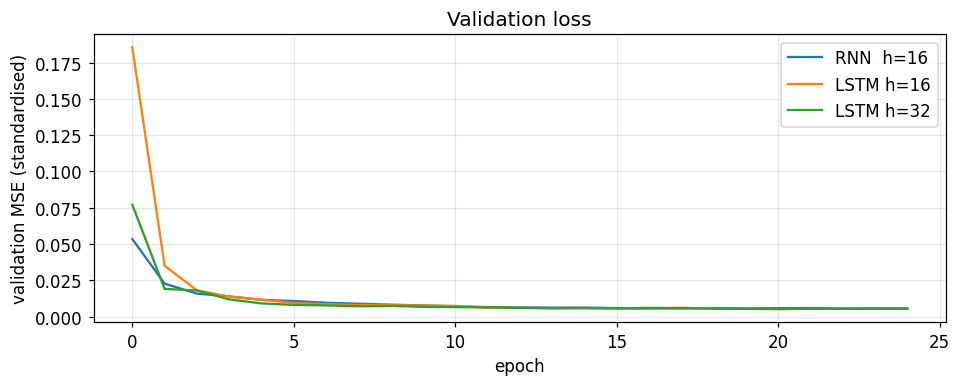

In [10]:
fig, ax = plt.subplots()
for name, hist in histories.items():
    ax.plot([v for _, v in hist], label=name)
ax.set_xlabel("epoch"); ax.set_ylabel("validation MSE (standardised)")
ax.set_title("Validation loss" + TAG); ax.legend()
fig.savefig(FIGS / "c05_fig01_val_loss.png"); plt.show()

## 6. The lag: what a model that has learned persistence looks like

A forecast plot where the prediction tracks the truth almost perfectly looks like success. Zoom in
and check *when* it does the tracking. If the predicted curve is the observed curve shifted one
step to the right, the model has learned to copy the last observation, and the plot is a picture
of persistence with extra steps.

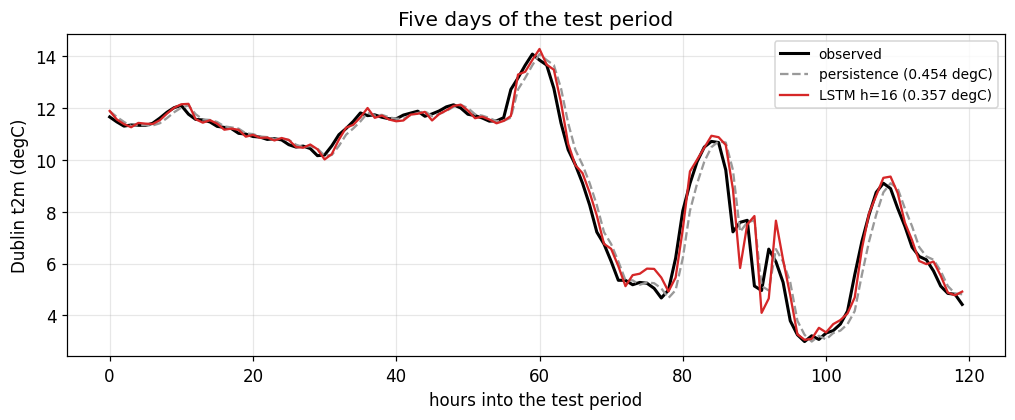

correlation between predicted change and actual change: 0.634
0 would mean the model is echoing the last observation and nothing more;
1 would mean it has the hour-to-hour change exactly right.


In [11]:
_, _, last_obs_te, truth_te = data["test"]
w = slice(0, 120)

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(truth_te[w, 0], "k", lw=2, label="observed")
ax.plot(last_obs_te[w, 0], color="0.6", ls="--", label=f"persistence ({RMSE_PERSIST:.3f} degC)")
ax.plot(preds["LSTM h=16"][w, 0], "C3", label=f"LSTM h=16 ({results['LSTM h=16']:.3f} degC)")
ax.set_ylabel("Dublin t2m (degC)"); ax.set_xlabel("hours into the test period")
ax.set_title("Five days of the test period" + TAG); ax.legend(loc="upper right", fontsize=9)
fig.savefig(FIGS / "c05_fig02_lag.png"); plt.show()

# how much does the model just echo the last observation?
model_change = preds["LSTM h=16"] - last_obs_te
true_change = truth_te - last_obs_te
rho = np.corrcoef(model_change.ravel(), true_change.ravel())[0, 1]
print(f"correlation between predicted change and actual change: {rho:.3f}")
print("0 would mean the model is echoing the last observation and nothing more;")
print("1 would mean it has the hour-to-hour change exactly right.")

## 7. Measuring the vanishing gradient, and what the cell state does about it

This is the intellectual centre of the lecture, and it is measurable in about fifteen lines.

Run a sequence of length 100 through an untrained cell and ask autograd: **how much does the final
hidden state depend on the input at step $t$?** Plot $\lVert \partial h_{100} / \partial x_t
\rVert$ against $t$ on a log scale.

For a vanilla RNN the gradient must pass through 100 factors of $W_{hh}^\top \odot \tanh'$ —
repeated matrix multiplication, which shrinks geometrically. For an LSTM the cell state path is
**additive**,

$$c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t
  \qquad\Longrightarrow\qquad \frac{\partial c_t}{\partial c_{t-1}} = f_t,$$

so travelling back one step multiplies by the forget gate rather than by a matrix. If the network
learns $f_t \approx 1$, information and gradient both travel a long way essentially unattenuated.
That contrast — repeated multiplication versus a near-identity path — is the whole idea, and it is
the same idea as the skip connections in ResNet from D2C2.

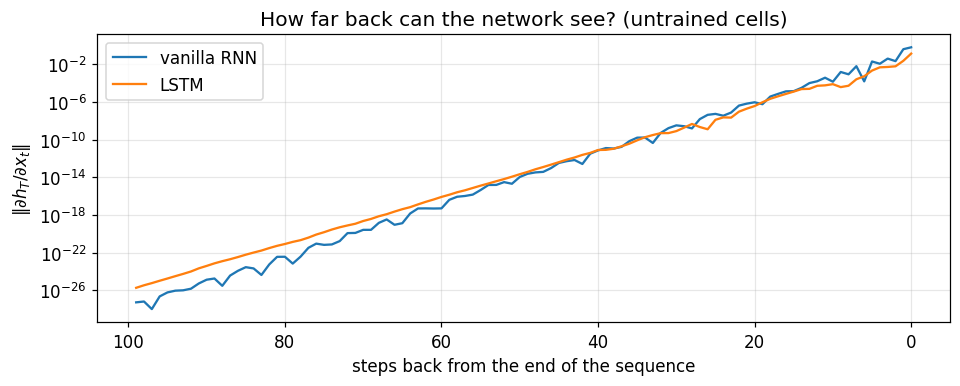

  1 steps back:  RNN 6.499e-01   LSTM 1.393e-01
 10 steps back:  RNN 1.556e-03   LSTM 3.845e-05
 30 steps back:  RNN 2.692e-09   LSTM 1.914e-09
 60 steps back:  RNN 4.077e-17   LSTM 1.420e-16


In [12]:
def gradient_reach(cell, T=100, hidden=16, seed=0):
    '''||d h_T / d x_t|| for every t, for an untrained cell.'''
    torch.manual_seed(seed)
    rec = nn.RNN(1, hidden, batch_first=True) if cell == "rnn" else nn.LSTM(1, hidden, batch_first=True)
    x = torch.randn(1, T, 1, requires_grad=True)
    out, _ = rec(x)
    out[0, -1, :].sum().backward()             # scalar summary of the final hidden state
    return x.grad[0, :, 0].abs().numpy()


g_rnn, g_lstm = gradient_reach("rnn"), gradient_reach("lstm")
steps_back = np.arange(100)[::-1]              # 0 = the last step

fig, ax = plt.subplots()
ax.semilogy(steps_back, np.maximum(g_rnn, 1e-30), label="vanilla RNN")
ax.semilogy(steps_back, np.maximum(g_lstm, 1e-30), label="LSTM")
ax.invert_xaxis()
ax.set_xlabel("steps back from the end of the sequence")
ax.set_ylabel(r"$\|\partial h_T / \partial x_t\|$")
ax.set_title("How far back can the network see? (untrained cells)"); ax.legend()
fig.savefig(FIGS / "c05_fig03_vanishing.png"); plt.show()

for k in (1, 10, 30, 60):
    print(f"{k:>3} steps back:  RNN {g_rnn[-k]:.3e}   LSTM {g_lstm[-k]:.3e}")

Both decay, and — this surprises people — an *untrained* LSTM decays no more slowly than the RNN.
Its forget gates sit near $\sigma(0) = 0.5$, so its cell path is multiplied by about a half per
step, and a half to the hundredth power is small too.

So the point is not that an LSTM never forgets. It is that the LSTM's decay rate is a **learned
parameter**: $f_t$ can move towards 1, and it does so wherever the task rewards remembering. The
RNN's decay rate is fixed by the spectrum of $W_{hh}$, and gradient descent has no way to push that
towards 1 without making the forward pass unstable.

The demonstration below makes that concrete: set the forget-gate bias high, so $f_t \approx 1$ at
initialisation, and the same LSTM reaches much further back. Initialising the forget bias to 1 is
standard practice for exactly this reason.

forget-gate bias 0: sigmoid(0) = 0.500  -> forgets fast
forget-gate bias 3: sigmoid(3) = 0.953  -> barely forgets
  1 steps back:  bias 0 1.359e-01   bias 3 5.949e-03
 10 steps back:  bias 0 4.698e-05   bias 3 3.384e-02
 30 steps back:  bias 0 4.764e-09   bias 3 6.854e-02
 60 steps back:  bias 0 1.415e-14   bias 3 8.929e-02


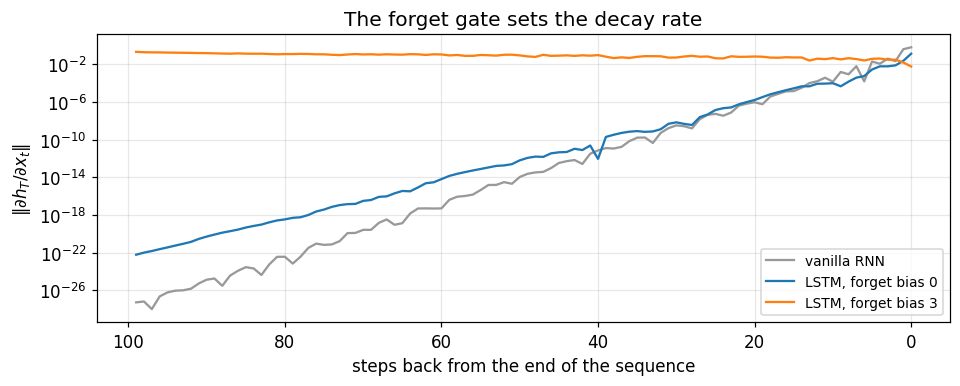

In [13]:
def gradient_reach_forget_bias(bias, T=100, hidden=16, seed=0):
    torch.manual_seed(seed)
    lstm = nn.LSTM(1, hidden, batch_first=True)
    with torch.no_grad():                      # PyTorch order: i, f, g, o
        lstm.bias_ih_l0[hidden:2 * hidden].fill_(bias)
        lstm.bias_hh_l0[hidden:2 * hidden].zero_()
    x = torch.randn(1, T, 1, requires_grad=True)
    out, _ = lstm(x)
    out[0, -1, :].sum().backward()
    return x.grad[0, :, 0].abs().numpy()


g_b0, g_b3 = gradient_reach_forget_bias(0.0), gradient_reach_forget_bias(3.0)
print(f"forget-gate bias 0: sigmoid(0) = {torch.sigmoid(torch.tensor(0.0)):.3f}  -> forgets fast")
print(f"forget-gate bias 3: sigmoid(3) = {torch.sigmoid(torch.tensor(3.0)):.3f}  -> barely forgets")
for k in (1, 10, 30, 60):
    print(f"{k:>3} steps back:  bias 0 {g_b0[-k]:.3e}   bias 3 {g_b3[-k]:.3e}")

fig, ax = plt.subplots()
ax.semilogy(steps_back, np.maximum(g_rnn, 1e-30), color="0.6", label="vanilla RNN")
ax.semilogy(steps_back, np.maximum(g_b0, 1e-30), label="LSTM, forget bias 0")
ax.semilogy(steps_back, np.maximum(g_b3, 1e-30), label="LSTM, forget bias 3")
ax.invert_xaxis()
ax.set_xlabel("steps back from the end of the sequence")
ax.set_ylabel(r"$\|\partial h_T / \partial x_t\|$")
ax.set_title("The forget gate sets the decay rate"); ax.legend(fontsize=9)
fig.savefig(FIGS / "c05_fig04_forget_bias.png"); plt.show()

## 8. Exercises

Each of these fails, or succeeds, informatively.

1. **Give the models something worth remembering.** Predict 24 hours ahead instead of 1
   (`y = z[T + 23:]`). Persistence collapses, and the gap between the models should open up. This
   is the single most instructive change in the notebook.
2. **Predict the change, not the level.** Train on $T_{t+1} - T_t$ and add the last observation
   back at the end. This is what made the CNN in D2C3 beat persistence; see whether it does the
   same here.
3. **Add wind as a second feature** (`input_size=2`). Does knowing the wind help forecast the
   temperature?
4. **Break the split on purpose.** Shuffle the rows before splitting and watch the test RMSE
   collapse to something implausibly good. Then explain to a colleague why it is nonsense.
5. **Remove `batch_first=True`** from `Tiny` without changing anything else. Note that it trains,
   converges, and produces a plausible-looking number that is wrong.
6. **Autoregressive rollout.** Feed the model's own prediction back as the next input and forecast
   ten hours ahead. Watch the error grow, and watch the forecast drift towards the training mean —
   which is what every autoregressive weather model does eventually, including the operational
   ones.